# Decomposition

## Global Importation

In [1]:
# Shape modules 
from collections import defaultdict

# Computational modules 
%matplotlib inline
import xarray as xr
import glob
import os
import numpy as np
import netCDF4
from netCDF4 import Dataset
import pandas as pd
import re
from array import array
from pylab import *
from scipy.stats import ttest_ind

#import geopandas
#from eofs.xarray import Eof
#from eofs.multivariate.standard import MultivariateEof
import random
import cftime

# Plotting modules 
import matplotlib.pyplot as plt

#from mpl_toolkits.basemap import Basemap
import pandas.plotting
import matplotlib.ticker as ticker

#import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from cartopy.util import add_cyclic_point
from shapely.geometry import Polygon as ShapelyPolygon

"""
# Scikit-learn
from sklearn import linear_model
from sklearn.linear_model import LassoCV, LassoLarsCV, LassoLarsIC
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn import preprocessing
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
from scipy.optimize import dual_annealing
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
import scipy.stats as stats
from scipy.stats import ttest_ind
"""

# Dask
import dask
"""
from dask import delayed, compute
from dask.distributed import Client
"""

# tqdm + Remove warnings
from tqdm import tqdm 
import warnings
warnings.filterwarnings('ignore')

ERROR 1: PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed


## Global Inset

### Load Temperature Data

In [2]:
path_tas_files = '/home/users/alvin_ch/files/Multi-model/UKESM_ramp_up/Surface_Temp'
filename = 'time_merged.nc'

level_list = ['esm-swl2p0', 'esm-swl3p0', 'esm-swl4p0', 'esm-swl5p0', 'esm-swl6p0']

files = [f'{path_tas_files}/{level_list[0]}_{filename}',
         f'{path_tas_files}/{level_list[1]}_{filename}',
         f'{path_tas_files}/{level_list[2]}_{filename}',
         f'{path_tas_files}/{level_list[3]}_{filename}',
         f'{path_tas_files}/{level_list[4]}_{filename}']

tas_time_merged = {scenario: {} for scenario in level_list}

for file, scenario in zip(tqdm(files), level_list): 
    results_open = xr.open_dataset(file)
    tas_time_merged[scenario] = results_open

100%|███████████████████████████████████████████| 5/5 [00:01<00:00,  2.86it/s]


### Standardise Coordinates

In [3]:
def standardise_coordinates(data):
    rename_dict = {}

    if 'lat' in data.coords:
        rename_dict['lat'] = 'latitude'

    if 'lon' in data.coords:
        rename_dict['lon'] = 'longitude'

    if rename_dict:
        data = data.rename(rename_dict)

    # Convert longitude from 0–360 to -180–180
    if data['longitude'].max() > 180:
        data = data.assign_coords(longitude=((data.longitude + 180) % 360) - 180)
        data = data.sortby('longitude')
    return data

## Processing Inset

### Define Boxes

In [4]:
import shapely.geometry as sgeom

def lon360_to_180(lon):
    return ((lon + 180) % 360) - 180

# Define box limits.
# No masking for all.

# TNA Boxing
tna_lon_min, tna_lon_max = lon360_to_180(320.0), lon360_to_180(345.0)   # degrees
tna_lat_min, tna_lat_max = 10.0, 20.0                                   # degrees

tna_poly = sgeom.Polygon([(tna_lon_min, tna_lat_min),   # SW corner
                          (tna_lon_max, tna_lat_min),   # SE corner
                          (tna_lon_max, tna_lat_max),   # NE corner
                          (tna_lon_min, tna_lat_max)])  # NW corner

# TSA Boxing
tsa_lon_min, tsa_lon_max = lon360_to_180(345.0), lon360_to_180(10.0)   # degrees
tsa_lat_min, tsa_lat_max = -5.0, 5.0                                   # degrees

tsa_poly = sgeom.Polygon([(tsa_lon_min, tsa_lat_min),  # SW corner
                          (tsa_lon_max, tsa_lat_min),  # SE corner
                          (tsa_lon_max, tsa_lat_max),  # NE corner
                          (tsa_lon_min, tsa_lat_max)]) # NW corner

# SPG Boxing
spg_lon_min, spg_lon_max = lon360_to_180(300.0), lon360_to_180(350.0)    # degrees
spg_lat_min, spg_lat_max = 50.0, 65.0                                    # degrees

# Define polygon (anti-clockwise order)
spg_poly = sgeom.Polygon([(spg_lon_min, spg_lat_min),  # SW corner
                          (spg_lon_max, spg_lat_min),  # SE corner
                          (spg_lon_max, spg_lat_max),  # NE corner
                          (spg_lon_min, spg_lat_max)]) # NW corner

In [5]:
tas_regions = {'tropical_north_atlantic': tna_poly, 'tropical_south_atlantic': tsa_poly, "subpolar_gyre": spg_poly}
tas_regions_list = ['tropical_north_atlantic', 'tropical_south_atlantic', 'subpolar_gyre']
seas_list = ['MJJAS']

### Polygon Mask

In [6]:
def polygon_mask(ds, polygon, lon_name="longitude", lat_name="latitude"):
    """
    Works for 1-D lon and lat (regular grids).
    Produces mask with dims (lat, lon).
    """

    lon = ds[lon_name].values        # shape (192,)
    lat = ds[lat_name].values        # shape (144,)

    # Build 2D coordinate grid
    lon2d, lat2d = np.meshgrid(lon, lat)

    # Check each grid point
    points = [sgeom.Point(x, y) for x, y in zip(lon2d.ravel(), lat2d.ravel())]
    inside = np.array([polygon.covers(pt) for pt in points])

    mask = inside.reshape(lat2d.shape)   # shape (144, 192)

    # Return DataArray with correct dims and coords
    return xr.DataArray(
        mask,
        dims=(ds[lat_name].dims[0], ds[lon_name].dims[0]),
        coords={ds[lat_name].dims[0]: ds[lat_name],
                ds[lon_name].dims[0]: ds[lon_name]}
    )

### Seasonal Average

In [7]:
def compute_seasonal_average_customed_MJJAS(data):

    # Keep only May–September
    data_mjjas = data.sel(time=data['time.month'].isin([5, 6, 7, 8, 9]))

    # Average over time
    seasonal_avg = data_mjjas.mean(dim='time')
    return seasonal_avg

def seasonal_average_over_years_customed_MJJAS(data) :
    year_list_tmp = data.groupby('time.year').mean()
    year_list = year_list_tmp['year'].values[:-1]
    avg_list = []

    for y in year_list:
        data_1yr = data.sel(time=slice(str(y), str(y)))
        avg = compute_seasonal_average_customed_MJJAS(data_1yr)
        avg_list.append(avg)

    # Concatenate in new Xarray
    # Create labeled coordinate array for the new dimension
    year_coord = xr.DataArray(year_list, dims='year')

    # Concatenate
    combined = xr.concat(avg_list, dim=year_coord)
    return combined

### Weighted Average

In [8]:
# This implementation is also used in the time series with land-sea mask applied.
def area_weighted_avg_masked(data):
    import numpy as np
    
    # Latitude weights: cosine of lat in radians
    lat_rad = np.radians(data['latitude'])
    lat_weights = np.cos(lat_rad)
    
    # Broadcast lat weights to full spatial dims
    # Assuming data dims: ('time', 'lat', 'lon') or similar
    weights = lat_weights.broadcast_like(data.isel(year=0))
    
    # Create a mask of valid (non-NaN) data points
    valid_mask = ~np.isnan(data)
    
    # Apply mask to weights (weights are zero where data is invalid)
    weights_masked = weights * valid_mask
    
    # Normalize weights so they sum to 1 along spatial dims for each time (or other dims)
    weights_sum = weights_masked.sum(dim=['latitude', 'longitude'])
    
    # Avoid division by zero (where weights_sum == 0)
    weights_sum = weights_sum.where(weights_sum != 0)
    
    # Compute weighted average
    weighted_avg = (data * weights_masked).sum(dim=['latitude', 'longitude']) / weights_sum
    return weighted_avg

## Processing 2 (SAT Analysis)

### Apply Polygon Mask

In [9]:
tas_regions = {'tropical_north_atlantic': tna_poly, 'tropical_south_atlantic': tsa_poly, "subpolar_gyre": spg_poly}
tas_regions_list = ['tropical_north_atlantic', 'tropical_south_atlantic', 'subpolar_gyre']
path_files = '/home/users/alvin_ch/files/Multi-model/UKESM_ramp_up/Decomposition'

polygon_masked_files = [f'{path_files}/{level_list[0]}_polygon_masked_tas_data.nc',
                        f'{path_files}/{level_list[1]}_polygon_masked_tas_data.nc',
                        f'{path_files}/{level_list[2]}_polygon_masked_tas_data.nc',
                        f'{path_files}/{level_list[3]}_polygon_masked_tas_data.nc',
                        f'{path_files}/{level_list[4]}_polygon_masked_tas_data.nc']

polygon_masked_data = {scenario: {} for scenario in level_list}

for (scenario, file_out) in zip(level_list, polygon_masked_files):
    ds = standardise_coordinates(tas_time_merged[scenario])

    for reg in tas_regions_list:
        region_mask = polygon_mask(ds['tas'], tas_regions[reg])
        data_reg = ds['tas'].where(region_mask, drop=True)
        polygon_masked_data[scenario][reg] = data_reg
        polygon_masked_data[scenario][reg] -= 273.15

In [10]:
print(polygon_masked_data[level_list[0]]['subpolar_gyre'].values[:1])

[[[-1.8067322e+00 -1.8443298e+00 -1.9027710e-01  1.1300354e+00
    1.8487854e+00  2.5487366e+00  3.0433655e+00  3.4239807e+00
    3.7699280e+00  4.1044006e+00  4.4088440e+00  4.6822815e+00
    4.9803772e+00  5.3087463e+00  5.6190491e+00  5.9388733e+00
    6.3561096e+00  6.7809143e+00  7.1756897e+00  7.5345764e+00
    7.9833069e+00  8.7198792e+00  9.3575745e+00  9.5760803e+00
    9.5143127e+00  9.3756409e+00  9.1676331e+00]
  [-7.4378357e+00 -5.4639587e+00 -1.3399353e+00  2.2695923e-01
    1.3126526e+00  2.0907288e+00  2.6427307e+00  2.9608459e+00
    3.2648010e+00  3.5809631e+00  3.8517151e+00  4.1085510e+00
    4.3553772e+00  4.6471252e+00  4.9571838e+00  5.2567444e+00
    5.6849670e+00  6.2106018e+00  6.6881409e+00  7.0912170e+00
    7.5848694e+00  8.3443909e+00  8.9427795e+00  9.1842346e+00
    9.1368713e+00  8.9815979e+00  8.1158752e+00]
  [-9.0699158e+00 -6.4441833e+00 -2.6326599e+00 -4.6200562e-01
    8.4487915e-01  1.7552795e+00  2.3465881e+00  2.6620178e+00
    2.8397522e+00  3

### Compute Weighted Average (GMSAT)

In [11]:
# Global data = tas_time_merged

### GLOBAL DATA ###

# Initialise dictionary for every scenario dataset.
global_avg = {scenario: {} for scenario in level_list}

for scenario in level_list:
    global_data = standardise_coordinates(tas_time_merged[scenario]['tas'])

    # Compute seasonal average.
    seas_avg_data = seasonal_average_over_years_customed_MJJAS(global_data)
    
    # Weighted Average.
    avg_reg = area_weighted_avg_masked(seas_avg_data)
    global_avg[scenario] = avg_reg - 273.15

In [12]:
global_avg[level_list[0]].values[:20]

array([17.24563254, 17.29962159, 17.32058842, 17.23050093, 17.22940352,
       17.23274252, 17.03330149, 17.09123427, 17.12637166, 17.28840464,
       17.1742231 , 17.32189245, 17.29813055, 17.34918931, 17.3454209 ,
       17.09401145, 17.13560911, 17.13904889, 17.29125118, 17.37008256])

### Compute Weighted Average (TNA and TSA)

In [13]:
# TNA data    = polygon_masked_data[scenario][tropical_north_atlantic]
# TSA data    = polygon_masked_data[scenario][tropical_south_atlantic]

tna_avg = {scenario: {} for scenario in level_list}
tsa_avg = {scenario: {} for scenario in level_list}
spg_avg = {scenario: {} for scenario in level_list}

### TNA ###

for scenario in level_list:
    data = polygon_masked_data[scenario]['tropical_north_atlantic']
    
    # Monsoonal Mean on the already region-masked data.
    seas_avg_data = seasonal_average_over_years_customed_MJJAS(data)

    # Weighted Average.
    avg_reg = area_weighted_avg_masked(seas_avg_data)
    tna_avg[scenario] = avg_reg

In [14]:
### TSA ###

for scenario in level_list:
    data = polygon_masked_data[scenario]['tropical_south_atlantic']
    
    # Monsoonal Mean on the already region-masked data.
    seas_avg_data = seasonal_average_over_years_customed_MJJAS(data)

    # Weighted Average.
    avg_reg = area_weighted_avg_masked(seas_avg_data)
    tsa_avg[scenario] = avg_reg

In [15]:
### SPG ###

for scenario in level_list:
    data = polygon_masked_data[scenario]['subpolar_gyre']
    
    # Monsoonal Mean on the already region-masked data.
    seas_avg_data = seasonal_average_over_years_customed_MJJAS(data)

    # Weighted Average.
    avg_reg = area_weighted_avg_masked(seas_avg_data)
    spg_avg[scenario] = avg_reg

In [16]:
spg_avg[scenario].values[:15]

array([13.99513123, 14.14809278, 15.50025602, 15.32320174, 14.4201955 ,
       13.91811083, 14.22791342, 15.19923465, 14.38103875, 14.32876403,
       14.00094554, 14.66747351, 14.48372192, 13.97445108, 14.84616294])

### Compute TNA-TSA

In [17]:
tna_tsa_diff = {scenario: {} for scenario in level_list}

for scenario in level_list:
    tna_tsa_diff[scenario] = tna_avg[scenario] - tsa_avg[scenario]

In [18]:
tna_tsa_diff[scenario].values[:15]

array([-2.47717887, -1.50515477, -1.67458471, -2.36795479, -2.80398926,
       -2.98347203, -2.34263802, -2.73965666, -2.83391785, -2.66601874,
       -2.60440877, -2.17596707, -2.76301981, -2.21450084, -2.65220184])

In [19]:
tna_tsa_diff[scenario]

<xarray.DataArray (year: 502)> Size: 4kB
array([-2.47717887, -1.50515477, -1.67458471, -2.36795479, -2.80398926,
       -2.98347203, -2.34263802, -2.73965666, -2.83391785, -2.66601874,
       -2.60440877, -2.17596707, -2.76301981, -2.21450084, -2.65220184,
       -3.33715502, -2.22115732, -2.71339209, -1.46763595, -1.95180531,
       -3.16083573, -2.3387423 , -1.15541115, -2.37784248, -2.71202211,
       -3.30940898, -2.92904428, -2.74373801, -3.03127742, -1.95675285,
       -1.64354315, -2.4122967 , -2.49061557, -2.37486008, -1.98169936,
       -1.93362089, -2.87593722, -2.92692141, -2.2024833 , -2.67155301,
       -2.45901558, -2.74754498, -2.92907586, -2.60492656, -3.60692661,
       -3.39223037, -3.10179278, -1.95134312, -2.71766217, -2.82691862,
       -2.70607431, -2.26484331, -3.44446273, -2.4313846 , -2.1843213 ,
       -2.54990653, -2.04649126, -3.0533854 , -2.86098314, -2.39390663,
       -2.73109444, -2.32684673, -2.31626325, -3.01670407, -2.76249832,
       -2.13457349, -2.72393232, -2.27774583, -2.87750814, -2.17297352,
       -3.3138864 , -3.25113973, -1.88526344, -2.67656133, -2.55254852,
       -2.6354838 , -2.2785147 , -2.48233928, -2.90723801, -1.85247859,
       -2.17304069, -2.34558491, -2.89078178, -2.18115948, -2.25940702,
       -3.25215264, -3.1309478 , -2.41045703, -3.08797396, -3.44810236,
       -2.5738224 , -1.97884606, -2.90321712, -3.24542359, -2.81128251,
       -2.99561207, -2.65618218, -2.59876719, -3.16149032, -3.20271879,
...
       -3.14763678, -3.36699544, -3.05486488, -3.02902878, -3.91900645,
       -3.25460919, -3.37452905, -2.63166327, -2.92498545, -2.77148426,
       -3.23026541, -3.37262608, -2.51007668, -2.71837402, -3.07627172,
       -2.79652813, -3.55017412, -3.41578387, -3.76325572, -3.65634915,
       -3.20348763, -3.45240434, -2.36888709, -3.32794493, -2.96686487,
       -3.16984643, -3.15837354, -2.9517255 , -2.67663605, -2.26662568,
       -2.93146466, -3.2108563 , -3.2281113 , -2.88222437, -3.43645945,
       -3.31669109, -3.97501828, -3.83884632, -3.99280861, -3.43028487,
       -3.24489455, -2.82383916, -3.53354205, -3.49249489, -3.04541089,
       -2.59587817, -3.01473815, -3.9176581 , -3.3479224 , -3.17058784,
       -4.07204977, -3.31376652, -2.91984423, -3.02368685, -4.2499643 ,
       -3.64094269, -3.48748948, -3.43050503, -3.6760294 , -3.36289517,
       -3.46912463, -3.1808703 , -3.51307733, -2.75795615, -2.27394644,
       -3.54774702, -2.5372621 , -2.81513657, -3.55519881, -3.96583651,
       -2.32582762, -2.71625475, -3.56839894, -4.15721252, -3.62768718,
       -2.93100538, -3.62781352, -3.76432881, -3.51078255, -3.45567291,
       -3.30762715, -3.12349389, -2.81094411, -3.28067441, -3.72104851,
       -3.42973544, -3.22275383, -3.5260389 , -3.66211454, -2.7842862 ,
       -3.74971258, -3.544652  , -3.5312206 , -2.63886431, -3.43539022,
       -2.97171416, -2.65706234])
Coordinates:
    height   float64 8B 1.5
  * year     (year) int64 4kB 2137 2138 2139 2140 2141 ... 2635 2636 2637 2638

### Compute SPG-GMSAT

In [21]:
spg_gmsat_diff = {scenario: {} for scenario in level_list}

for scenario in level_list:
    spg_gmsat_diff[scenario] = spg_avg[scenario] - global_avg[scenario]

## Processing 3 (Compute Anomalies)

In [22]:
# For each component, compute the anomaly.
# Relative to the mean of the first 100 years.

anomaly_vals = {scenario: {} for scenario isn level_list}

for scenario in level_list:
    # Recall data for each component
    data_global = global_avg[scenario]
    data_tna_tsa = tna_tsa_diff[scenario]
    data_spg_gmsat = spg_gmsat_diff[scenario]

    # Extract first 100 years
    global_first = data_global.values[:100].mean()
    tna_tsa_first = data_tna_tsa.values[:100].mean()
    spg_gmsat_first = data_spg_gmsat.values[:100].mean()

    anom_global = data_global.values - global_first
    anom_tna_tsa = data_tna_tsa.values - tna_tsa_first
    anom_spg_gmsat = data_spg_gmsat.values - spg_gmsat_first

    anomaly_vals[scenario]['GMSAT'] = anom_global
    anomaly_vals[scenario]['TNA-TSA'] = anom_tna_tsa
    anomaly_vals[scenario]['SPG-GMSAT'] = anom_spg_gmsat

In [23]:
anomaly_vals[level_list[0]]['GMSAT'][:10]

array([ 0.02828037,  0.08226941,  0.10323624,  0.01314876,  0.01205134,
        0.01539035, -0.18405069, -0.1261179 , -0.09098052,  0.07105246])

In [24]:
anomaly_vals[level_list[0]]['TNA-TSA'][:10]

array([ 0.35261962,  0.10546311,  0.26536045,  0.39836686,  0.870227  ,
        0.10943716,  0.22385282,  0.43797621,  0.08879278, -0.87439082])

In [25]:
anomaly_vals[level_list[0]]['SPG-GMSAT'][:10]

array([ 0.70082601, -0.01204662, -0.35446375, -1.04035869, -0.30489999,
        0.48369954,  1.28758097,  0.22728209,  0.45697019, -0.04284671])

## Results Review 2 (GMSAT, TNA-TSA Time Series)

### Implementation (Plot)

In [27]:
# Check that the lengths for each is the same.

print(np.allclose(len(spg_gmsat_diff[scenario]), len(global_avg[scenario])))
print(np.allclose(len(tna_tsa_diff[scenario]), len(global_avg[scenario])))
print(len(global_avg[scenario]))

True
True
502


In [28]:
# The input for decompose_data is the dataset corresponding to the senario input.
# Data input is the last 100 and first 100 years anomaly.
def gmsat_tna_tsa_time_series(anomaly_vals, scenario_list, labels_list, colour_list, trend_vals_dict):

    # Titles and labels for each decomposition.
    variable_labels = {'GMSAT': 'GMSAT',
                       'TNA-TSA': 'TNA-TSA',
                       'SPG-GMSAT': 'SPG-GMSAT'}
    
    # Set up figure.
    fig, axes = plt.subplots(5, 1, figsize=(20, 10), sharex=True, constrained_layout=True)
    
    # Plot each scenario in its own panel.
    for i, scenario in enumerate(scenario_list):
        ax = axes[i] 

        # Store trend labels for this panel.
        trend_labels = []

        variables = [('GMSAT', anomaly_vals[scenario]['GMSAT']),
                     ('TNA-TSA', anomaly_vals[scenario]['TNA-TSA']),
                     ('SPG-GMSAT', anomaly_vals[scenario]['SPG-GMSAT'])]
        
        # Loop through the four decomposition variables. 
        for (variable, data), colour in zip(variables, colour_list):

            years_since_start = np.arange(len(data))
            
            y_smooth = pd.Series(data).rolling(5, center=True, min_periods=5).mean().values

            ax.plot(years_since_start, y_smooth, label=variable_labels[variable], color=colour, linewidth=0.75)

            # Calculate linear trend from the original data.
            mask = ~np.isnan(data)

            if mask.sum() > 1:
                coeffs = np.polyfit(years_since_start[mask], data[mask], 1)

                slope_per_year = coeffs[0]
                slope_per_decade = slope_per_year * 10

                trend = np.poly1d(coeffs)(years_since_start)
                trend_labels.append(f'{variable_labels[variable]} trend: {slope_per_decade:+.4f} °C/decade')
                trend_vals_dict[scenario][variable] = slope_per_decade
                
                ax.plot(years_since_start, trend, linestyle='--', color=colour, linewidth=2.5, alpha=0.8)

            # Formatting.
            ax.grid(axis='both', alpha=0.3)
            ax.set_yticks(np.arange(-1, 1.5, 0.5))
            
            if i % 2 == 0:
                ax.spines['right'].set_visible(False)
                ax.spines['top'].set_visible(False)
            else: 
                ax.spines['left'].set_visible(False)
                ax.spines['top'].set_visible(False)
                ax.yaxis.tick_right()
                ax.yaxis.set_label_position('right')

            if ax == axes[0]:
                ax.spines['top'].set_visible(True)

            # Add trend labels to each panel.
            ax.text(0.82, 0.98, '\n'.join(trend_labels), transform=ax.transAxes, ha='left', va='top',
                    fontsize=10, bbox=dict(boxstyle='round,pad=0.3',
                                           facecolor='white',
                                           edgecolor='black',
                                           alpha=0.8))
            
            # Scenario labels
            if i % 2 == 0:
                ax.text(-0.08, 0.5, labels_list[i], transform=ax.transAxes, ha='right', va='center', fontsize=14,
                        rotation=90, bbox=dict(boxstyle='round,pad=0.4',
                                               facecolor='white',
                                               edgecolor='black',
                                               linewidth=1))
                
            else:
                ax.text(1.08, 0.5, labels_list[i], transform=ax.transAxes, ha='left', va='center', fontsize=14,
                        rotation=90, bbox=dict(boxstyle='round,pad=0.4',
                                               facecolor='white',
                                               edgecolor='black',
                                               linewidth=1))
        
        # Common x-axis label.
        axes[-1].set_xlabel('Years (since start of simulation)', fontsize=14)
        
        # y-axis label.
        for ax in axes:
            ax.set_ylabel('Temperature (°C)', fontsize=12) 
        
        for ax in axes[:-1]:
            ax.tick_params(axis='x', labelbottom=False)

    # Common legend.
    handles_left, labels_left = axes[0].get_legend_handles_labels()

    axes[1].legend(handles_left, labels_left, loc='lower right', frameon=True, fontsize=11)
            
    fig.suptitle('Evolution of GMSAT, TNA-TSA and SPG-GMSAT', fontsize=20)

    if save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)
    plt.show()

### Resultant Plot

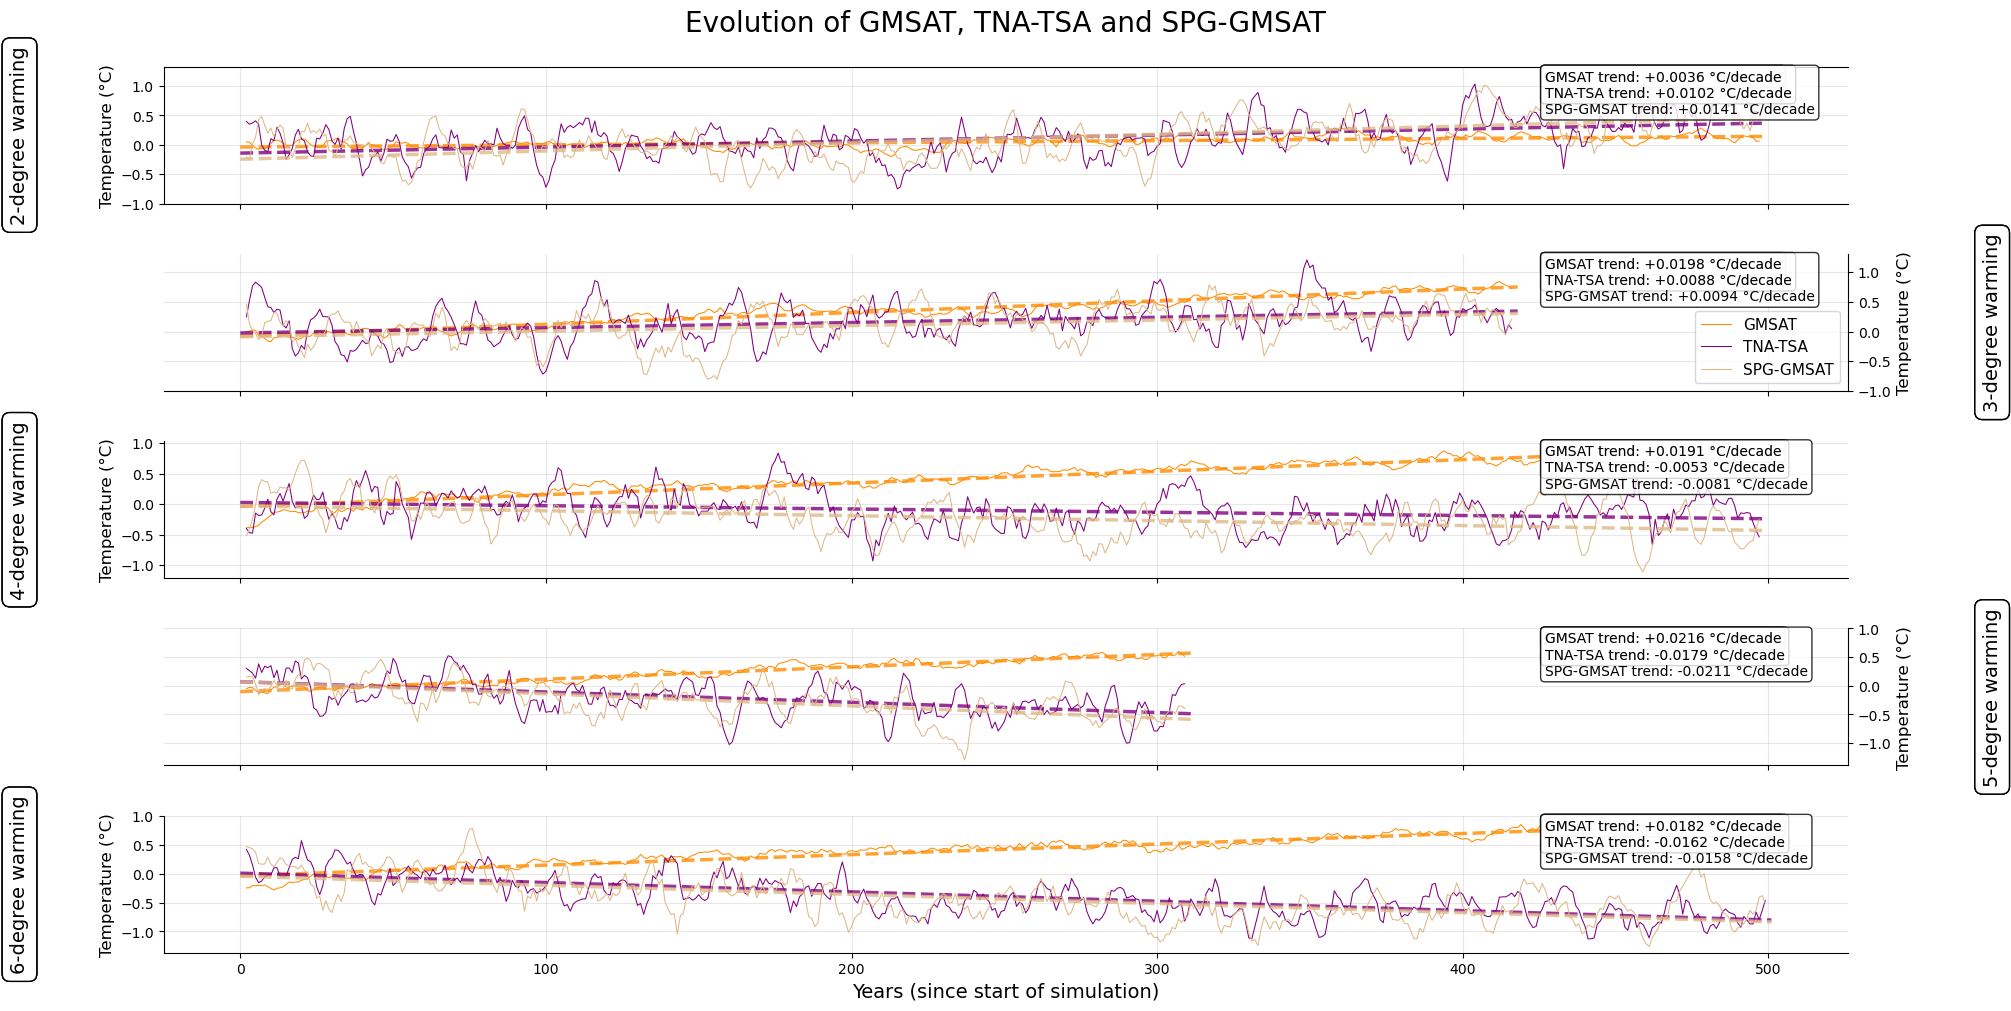

In [29]:
colour_list = ['darkorange', 'purple', 'burlywood']
trend_vals_dict = {scenario: {} for scenario in level_list}

names = ['2-degree warming', '3-degree warming', '4-degree warming', '5-degree warming', '6-degree warming']

save = True
save_path = '/home/users/alvin_ch/figures/Multi-model/UKESM_ramp_up/Decomposition'
filename = f'{save_path}/GMSAT_TNA-TSA_time_series.png'

gmsat_tna_tsa_time_series(anomaly_vals, level_list, names, colour_list, trend_vals_dict)

## $\Delta$[TNA-TSA] vs $\Delta$Variables

### Recall Previous Notebook

In [ ]:
%run decomposition_3.ipynb

ERROR 1: PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed
100%|███████████████████████████████████████████| 5/5 [00:02<00:00,  2.42it/s]


<xarray.DataArray 'sftlf' ()> Size: 8B
array(9320)
Coordinates:
    type     |S4 4B b'land'


In [31]:
# This is the dictionary we are using for this subsection.
trend_vals_store_dict

{'2-degree warming': {'delta_precip': np.float64(0.0007426291608999138),
  'thermodynamic': np.float64(0.00022392832200557946),
  'dynamic': np.float64(0.000517558281126875),
  'cross_term': np.float64(1.1425722195822792e-06)},
 '3-degree warming': {'delta_precip': np.float64(-0.0002828582307909857),
  'thermodynamic': np.float64(0.0006062231297842968),
  'dynamic': np.float64(-0.0010217623811475335),
  'cross_term': np.float64(0.00013268103460868606)},
 '4-degree warming': {'delta_precip': np.float64(-0.004515333591174002),
  'thermodynamic': np.float64(-0.0011245033165446878),
  'dynamic': np.float64(-0.0035420148899927527),
  'cross_term': np.float64(0.0001511846133672793)},
 '5-degree warming': {'delta_precip': np.float64(-0.0081140752605022),
  'thermodynamic': np.float64(-0.002335204594089817),
  'dynamic': np.float64(-0.005993916058977564),
  'cross_term': np.float64(0.00021504543872067624)},
 '6-degree warming': {'delta_precip': np.float64(-0.003293032325831519),
  'thermodynam

### Pre-Plot Processing

In [32]:
# y-axis: variable trend values
variable_list = ['delta_precip', 'thermodynamic', 'dynamic']
names = ['2-degree warming', '3-degree warming', '4-degree warming', '5-degree warming', '6-degree warming']

# New lists
# Store values according to variable.
# The order of values is in ascending degree-warming order
delta_precip_trends = []
thermodynamic_trends = []
dynamic_trends = []

for var in variable_list:
    for scenario in names:
        value = trend_vals_store_dict[scenario][var]
        if var == 'delta_precip':
            delta_precip_trends.append(value)
        elif var == 'thermodynamic':
            thermodynamic_trends.append(value)
        else:
            dynamic_trends.append(value)

In [33]:
# Check values
delta_precip_trends

[np.float64(0.0007426291608999138),
 np.float64(-0.0002828582307909857),
 np.float64(-0.004515333591174002),
 np.float64(-0.0081140752605022),
 np.float64(-0.003293032325831519)]

In [34]:
# x-axis: TNA-TSA trend values
tna_tsa_diff_trends = []

for scenario in level_list:
    val = trend_vals_dict[scenario]['TNA-TSA']
    tna_tsa_diff_trends.append(val)

In [35]:
tna_tsa_diff_trends

[np.float64(0.010235666520860123),
 np.float64(0.008815913335467777),
 np.float64(-0.005333093881605062),
 np.float64(-0.017944159877626462),
 np.float64(-0.016195252498796386)]

### Plot

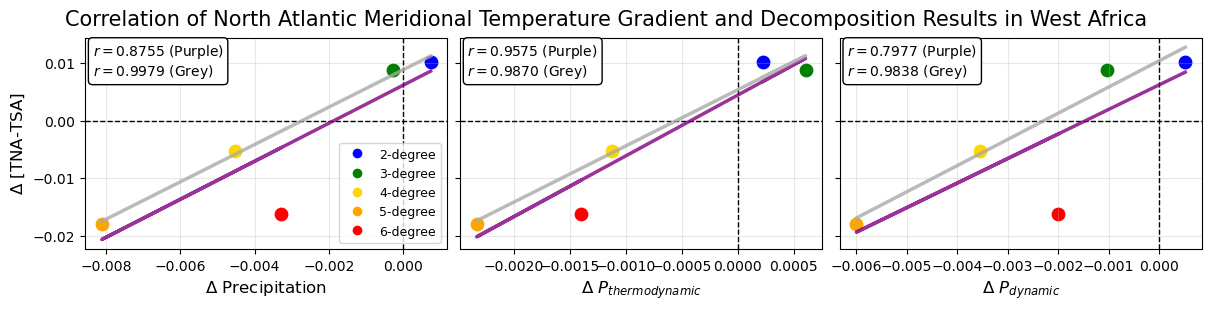

In [37]:
from matplotlib.lines import Line2D

# Align values.
x_vals = [delta_precip_trends, thermodynamic_trends, dynamic_trends]
y = tna_tsa_diff_trends

# Each colour represents a different scenario.
# Blue = 2-degree
# Red = 6-degree
point_colours = ['blue', 'green', 'gold', 'orange', 'red']

# Set up figure
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True, constrained_layout=True)
axes = axes.flatten()

for i, x in enumerate(x_vals):
    ax = axes[i] 
    x_values = x
    y_values = y

    assert len(x_values) == len(y_values)
    assert len(x_values) == len(point_colours)

    corr_labels = []
    
    ax.grid(axis='both', alpha=0.3)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    
    for j in range(len(point_colours)):
        ax.scatter(x_values[j], y_values[j], color=point_colours[j], s=80)

    # Plot correlation
    
    # All values
    coeffs = np.polyfit(x_values, y_values, 1)
    trend = np.poly1d(coeffs)(x_values)

    r, p = pearsonr(x_values, y_values)
    r_squared = r**2
    corr_labels.append(f'$r = {r:.4f}$ (Purple)')
    ax.plot(x_values, trend, color='purple', linewidth=2.5, alpha=0.8)
    
    # Exclude outlier
    coeffs = np.polyfit(x_values[:4], y_values[:4], 1)
    trend = np.poly1d(coeffs)(x_values[:4])
    
    r, p = pearsonr(x_values[:4], y_values[:4])
    r_squared = r**2
    corr_labels.append(f'$r = {r:.4f}$ (Grey)')
    ax.plot(x_values[:4], trend, color='darkgray', linewidth=2.5, alpha=0.8)

    ax.text(0.02, 0.98, '\n'.join(corr_labels), transform=ax.transAxes, ha='left', va='top',
            fontsize=10, bbox=dict(boxstyle='round,pad=0.3',
                                   facecolor='white',
                                   edgecolor='black',
                                   alpha=1.0))

# Legend for scenarios.
legend_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=point_colours[i],
                         markersize=8, label=f'{i + 2}-degree') for i in range(len(point_colours))]

# Formatting
axes[0].set_ylabel('$\Delta$ [TNA-TSA]', fontsize=12)
axes[0].set_xlabel('$\Delta$ Precipitation', fontsize=12)
axes[1].set_xlabel('$\Delta$ $P_{thermodynamic}$', fontsize=12)
axes[2].set_xlabel('$\Delta$ $P_{dynamic}$', fontsize=12)

# Add legend
axes[0].legend(handles=legend_handles, loc='best', frameon=True, fontsize=9)

# Title
fig.suptitle('Correlation of North Atlantic Meridional Temperature Gradient and Decomposition Results in West Africa', fontsize=15)

path_figure = '/home/users/alvin_ch/figures/Multi-model/UKESM_ramp_up/Decomposition'
filename = f'{path_figure}/correlation_trend_tna-tsa_against_decomp_variables.png'

plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)
plt.show();